In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
df = pd.read_csv("retail_transactional_raw_dataset.csv")
df["Region"] = df["Region"].fillna("Unknown")
df["Stock_Qty"] = df["Stock_Qty"].fillna(0)
df["Discount"] = df["Discount"].fillna(0)


Inventory Days vs Profit Correlation: 0.177


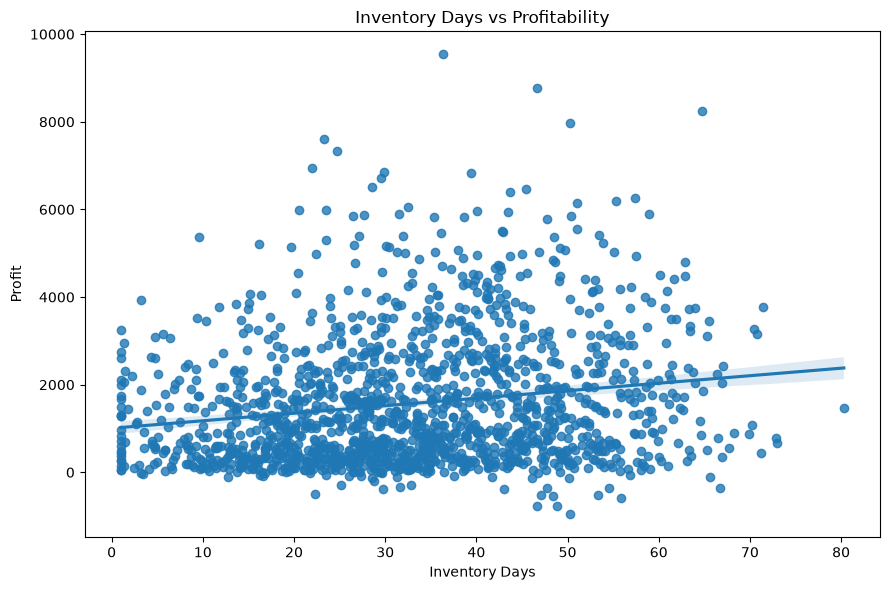

In [12]:
correlation = df["Inventory_Days"].corr(df["Profit"])
print("\nInventory Days vs Profit Correlation:", round(correlation, 3))

plt.figure(figsize=(9, 6))
sns.regplot(data=df, x="Inventory_Days", y="Profit")
plt.title("Inventory Days vs Profitability")
plt.xlabel("Inventory Days")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()


Seasonal Product Behavior:
     Season        Category  Units_Sold     Revenue     Profit
0   Festive          Beauty         257   164592.75   63663.56
1   Festive        Clothing         304   348328.82  117743.49
2   Festive     Electronics         348   723518.91   83639.70
3   Festive         Grocery         218   100554.07   16337.18
4   Festive  Home & Kitchen         374   667755.60  164329.85
5   Monsoon          Beauty         578   352974.58  136262.26
6   Monsoon        Clothing         555   664396.04  224125.43
7   Monsoon     Electronics         612  1273337.12  163782.88
8   Monsoon         Grocery         553   236446.49   34674.67
9   Monsoon  Home & Kitchen         482   848664.57  193475.40
10   Summer          Beauty         383   243988.89  100879.10
11   Summer        Clothing         440   484739.10  168202.51
12   Summer     Electronics         400   878538.79  123076.77
13   Summer         Grocery         369   168916.29   27481.59
14   Summer  Home & Kitchen

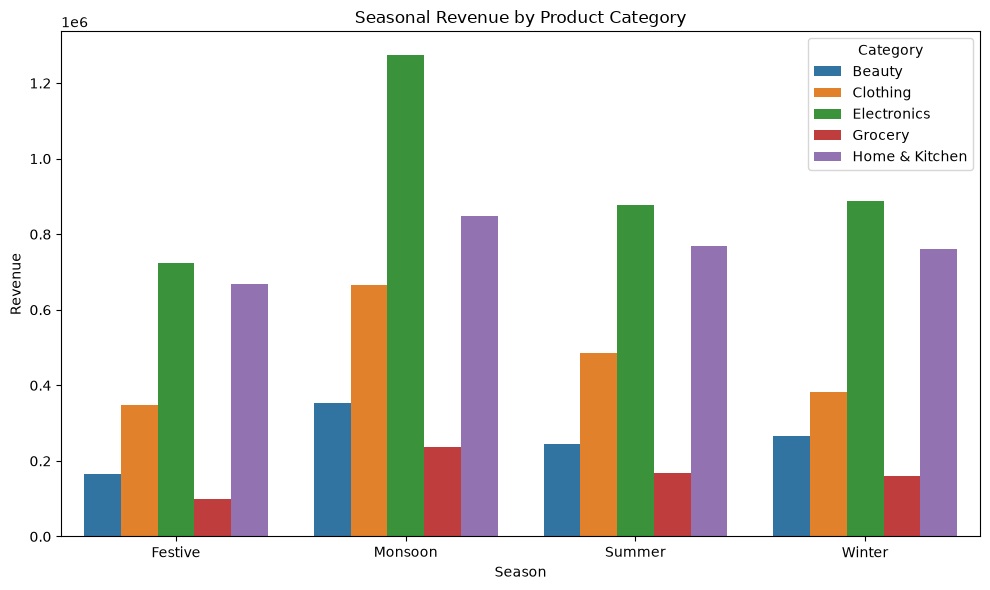

In [13]:
seasonal_analysis = df.groupby(
    ["Season", "Category"]
).agg(
    Units_Sold=("Quantity_Sold", "sum"),
    Revenue=("Revenue", "sum"),
    Profit=("Profit", "sum")
).reset_index()

print("\nSeasonal Product Behavior:")
print(seasonal_analysis.round(2))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=seasonal_analysis,
    x="Season",
    y="Revenue",
    hue="Category"
)
plt.title("Seasonal Revenue by Product Category")
plt.xlabel("Season")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

In [14]:
inventory_analysis = df.groupby(
    ["Category", "Sub_Category"]
).agg(
    Units_Sold=("Quantity_Sold", "sum"),
    Avg_Stock=("Stock_Qty", "mean"),
    Avg_Inventory_Days=("Inventory_Days", "mean"),
    Profit=("Profit", "sum")
).reset_index()

slow_moving = inventory_analysis[
    inventory_analysis["Avg_Inventory_Days"] >= 40
].sort_values("Avg_Inventory_Days", ascending=False)

overstocked = inventory_analysis[
    (inventory_analysis["Avg_Stock"] >= 100) &
    (inventory_analysis["Avg_Inventory_Days"] >= 35)
].sort_values("Avg_Stock", ascending=False)

print("\nSlow-Moving Products:")
print(slow_moving.round(2))

print("\nOverstocked Products:")
print(overstocked.round(2))


Slow-Moving Products:
       Category       Sub_Category  Units_Sold  Avg_Stock  Avg_Inventory_Days  \
8   Electronics  Bluetooth Speaker         467      98.35               45.92   
9   Electronics         Headphones         428      88.70               44.27   
11  Electronics         Smartwatch         482      96.98               44.26   
10  Electronics         Power Bank         374      87.82               43.67   
6      Clothing              Kurta         487      82.84               41.99   
5      Clothing              Jeans         347      91.70               41.29   

       Profit  
8   141706.01  
9   115362.97  
11  139476.15  
10   96697.80  
6   190405.06  
5   137525.36  

Overstocked Products:
Empty DataFrame
Columns: [Category, Sub_Category, Units_Sold, Avg_Stock, Avg_Inventory_Days, Profit]
Index: []
